In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.ensemble import RandomForestClassifier

In [41]:
model_data = pd.read_csv(
    "../data/processed/model_data.csv",
    parse_dates=["date"]
)

In [42]:
features = [
    "unemployment",
    "yield_curve",
    "fed_funds_rate",
    "inflation_yoy",
    "industrial_growth_yoy",
    "housing_growth_yoy",
    "unemployment_change_3m",
    "claims_change_3m",
    "consumer_sentiment"
]

In [43]:
train = model_data[
    model_data["date"] < "2016-01-01"
].copy()

test = model_data[
    model_data["date"] >= "2016-01-01"
].copy()

In [44]:
X_train = train[features]
y_train = train["recession_next_6m"]

X_test = test[features]
y_test = test["recession_next_6m"]

In [45]:
baseline_pred = np.zeros(len(y_test))

In [46]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.9416666666666667


In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [49]:
logit.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [50]:
logit_pred = logit.predict(
    X_test_scaled
)

In [51]:
logit_prob = logit.predict_proba(
    X_test_scaled
)[:, 1]

In [52]:
print(
    "Accuracy:",
    accuracy_score(y_test, logit_pred)
)

print(
    "Precision:",
    precision_score(y_test, logit_pred)
)

print(
    "Recall:",
    recall_score(y_test, logit_pred)
)

print(
    "F1:",
    f1_score(y_test, logit_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, logit_prob)
)

Accuracy: 0.5166666666666667
Precision: 0.05263157894736842
Recall: 0.42857142857142855
F1: 0.09375
ROC-AUC: 0.5651074589127687


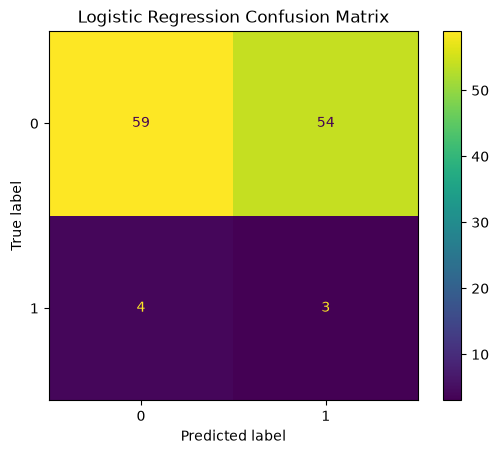

In [53]:
cm = confusion_matrix(
    y_test,
    logit_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

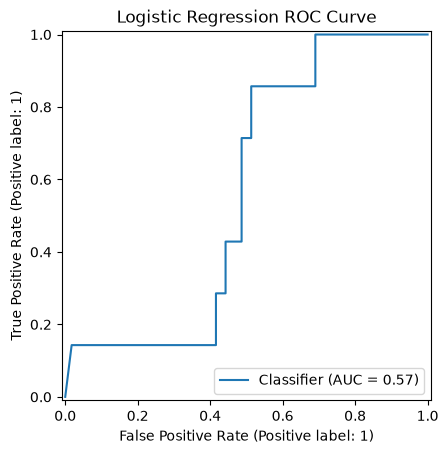

In [54]:
RocCurveDisplay.from_predictions(
    y_test,
    logit_prob
)

plt.title(
    "Logistic Regression ROC Curve"
)

plt.show()

In [55]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": logit.coef_[0]
})

coefficients = coefficients.sort_values(
    "coefficient",
    ascending=False
)

coefficients

,feature,coefficient
6,unemployment_change_3m,1.071423
2,fed_funds_rate,0.871556
1,yield_curve,0.735433
7,claims_change_3m,0.676586
3,inflation_yoy,0.353250
8,consumer_sentiment,-0.543544
5,housing_growth_yoy,-1.208478
4,industrial_growth_yoy,-1.620599
0,unemployment,-3.231220


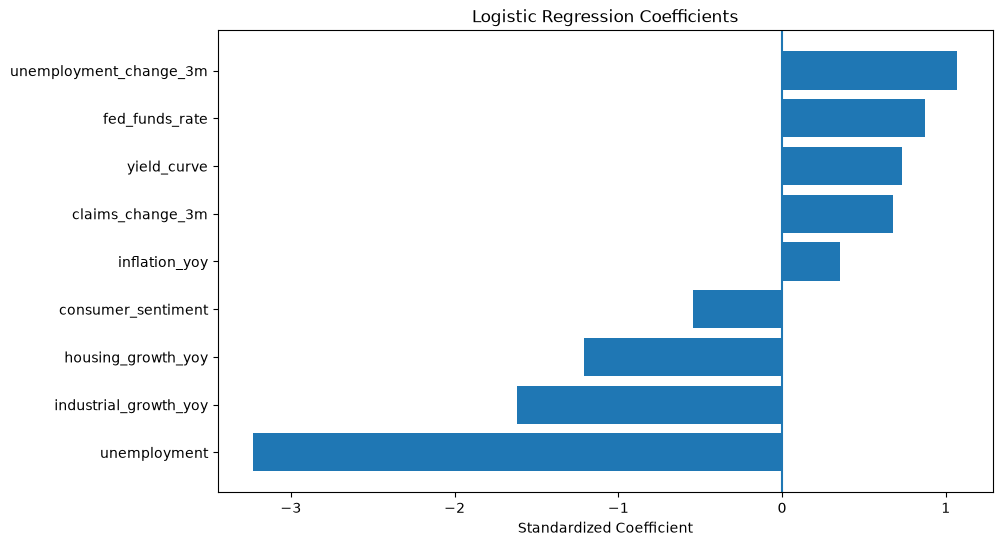

In [56]:
coefficients_plot = coefficients.sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    coefficients_plot["feature"],
    coefficients_plot["coefficient"]
)

plt.axvline(0)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Standardized Coefficient")

plt.show()

In [57]:
test_results = test.copy()

test_results["predicted_probability"] = logit_prob

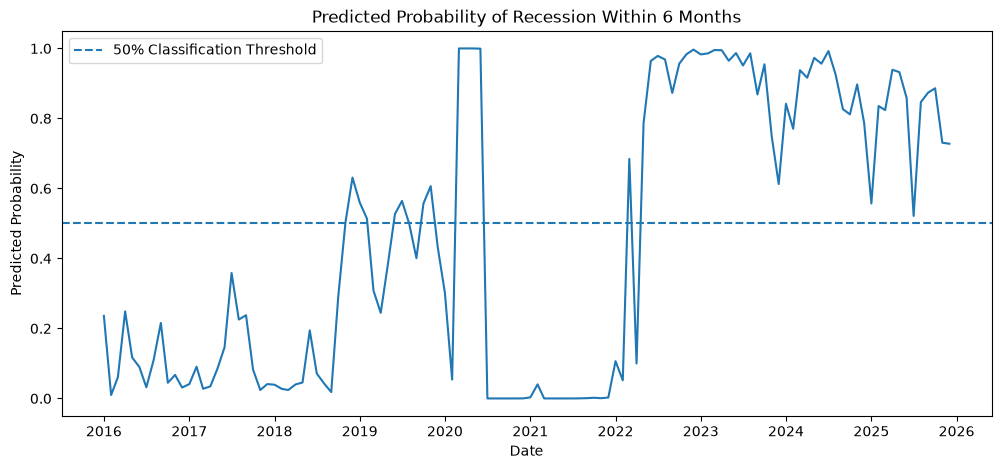

In [58]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_results["date"],
    test_results["predicted_probability"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% Classification Threshold"
)

plt.title("Predicted Probability of Recession Within 6 Months")
plt.xlabel("Date")
plt.ylabel("Predicted Probability")
plt.legend()

plt.show()

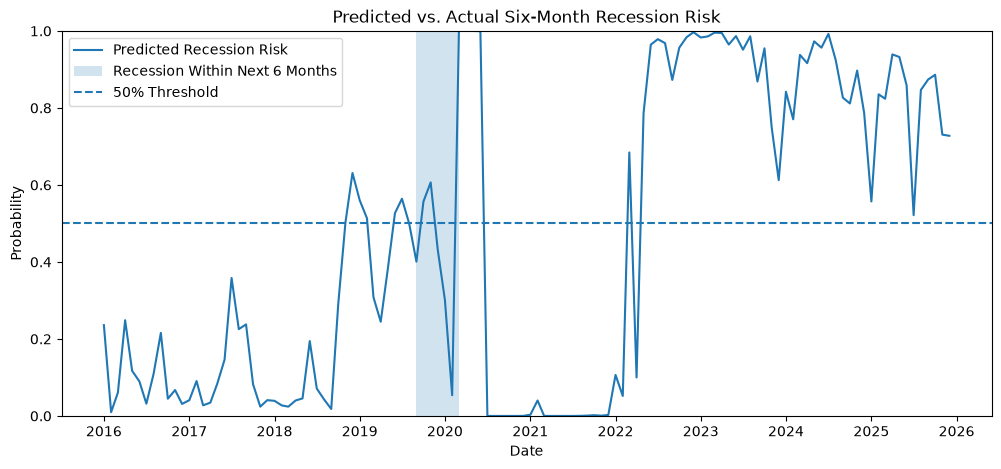

In [59]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_results["date"],
    test_results["predicted_probability"],
    label="Predicted Recession Risk"
)

plt.fill_between(
    test_results["date"],
    0,
    1,
    where=test_results["recession_next_6m"] == 1,
    alpha=0.2,
    label="Recession Within Next 6 Months"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% Threshold"
)

plt.ylim(0, 1)

plt.title("Predicted vs. Actual Six-Month Recession Risk")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()

plt.show()

In [60]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

In [61]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [62]:
rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:, 1]

In [63]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

Accuracy: 0.725
Precision: 0.06666666666666667
Recall: 0.2857142857142857
F1: 0.10810810810810811
ROC-AUC: 0.5941845764854614


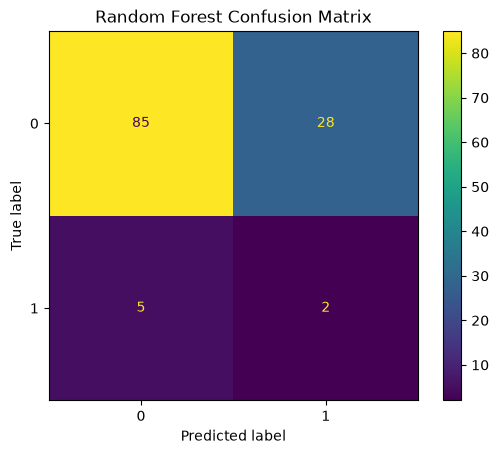

In [64]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp_rf.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

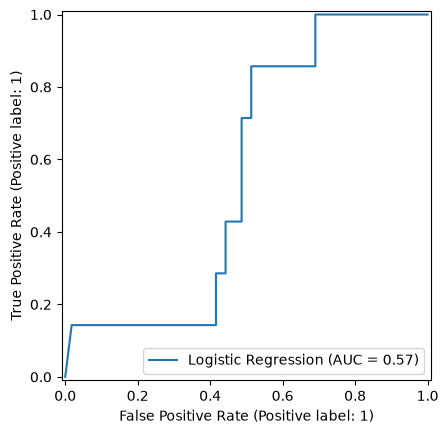

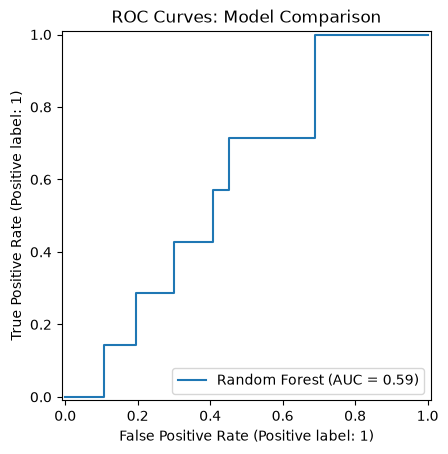

In [65]:
RocCurveDisplay.from_predictions(
    y_test,
    logit_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curves: Model Comparison")

plt.show()

In [66]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
)

rf_importance

,feature,importance
7,claims_change_3m,0.241673
4,industrial_growth_yoy,0.214091
6,unemployment_change_3m,0.183337
5,housing_growth_yoy,0.138634
3,inflation_yoy,0.060076
0,unemployment,0.059648
1,yield_curve,0.038591
8,consumer_sentiment,0.032254
2,fed_funds_rate,0.031696


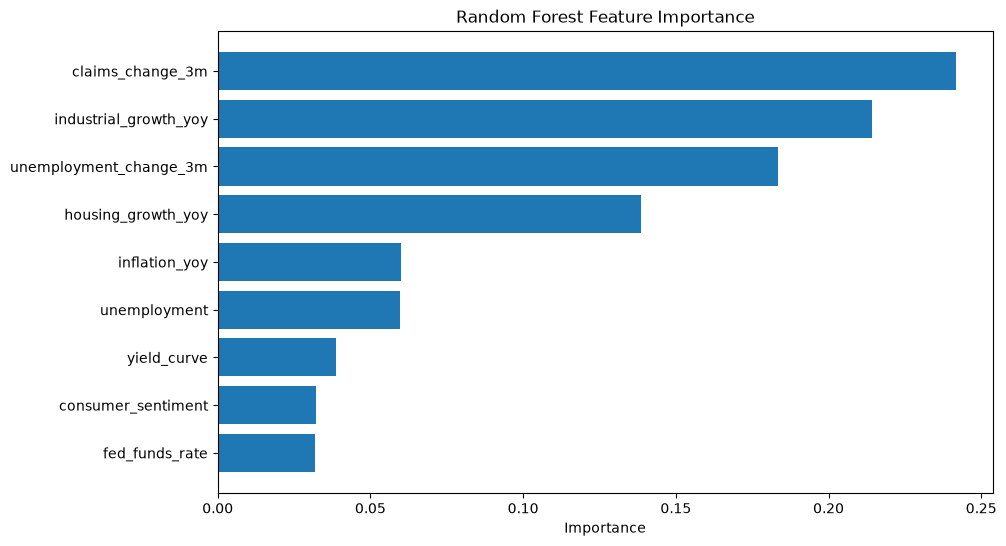

In [67]:
rf_importance_plot = rf_importance.sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_plot["feature"],
    rf_importance_plot["importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

In [68]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, logit_pred),
        accuracy_score(y_test, rf_pred)
    ],
    
    "Precision": [
        precision_score(y_test, logit_pred),
        precision_score(y_test, rf_pred)
    ],
    
    "Recall": [
        recall_score(y_test, logit_pred),
        recall_score(y_test, rf_pred)
    ],
    
    "F1": [
        f1_score(y_test, logit_pred),
        f1_score(y_test, rf_pred)
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, logit_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.516667,0.052632,0.428571,0.093750,0.565107
1,Random Forest,0.725000,0.066667,0.285714,0.108108,0.594185


In [69]:
y_test.value_counts()

recession_next_6m
0.0    113
1.0      7
Name: count, dtype: int64

In [70]:
y_test.value_counts(normalize=True)

recession_next_6m
0.0    0.941667
1.0    0.058333
Name: proportion, dtype: float64

In [71]:
import numpy as np

baseline_pred = np.zeros(len(y_test))

In [72]:
print(
    "Baseline Accuracy:",
    accuracy_score(y_test, baseline_pred)
)

print(
    "Baseline Recall:",
    recall_score(y_test, baseline_pred)
)

print(
    "Baseline F1:",
    f1_score(y_test, baseline_pred)
)

Baseline Accuracy: 0.9416666666666667
Baseline Recall: 0.0
Baseline F1: 0.0


Model Comparison

Logistic regression and random forest models were evaluated using a chronological train-test split to preserve the time-series structure of the data. Because recession-warning months are rare, accuracy alone is not an appropriate measure of model performance.

The random forest reduced the number of false-positive recession signals relative to logistic regression and achieved a slightly higher ROC-AUC. However, both models showed limited ability to distinguish recession-warning months from normal periods in the test sample. The small number of positive observations also makes the evaluation metrics highly sensitive to individual recession episodes.

These results illustrate an important challenge in recession forecasting: historical macroeconomic relationships do not necessarily generalize cleanly across economic regimes. Rather than demonstrating highly accurate recession prediction, the models provide a framework for examining which macroeconomic indicators contain predictive information and where those relationships break down. 

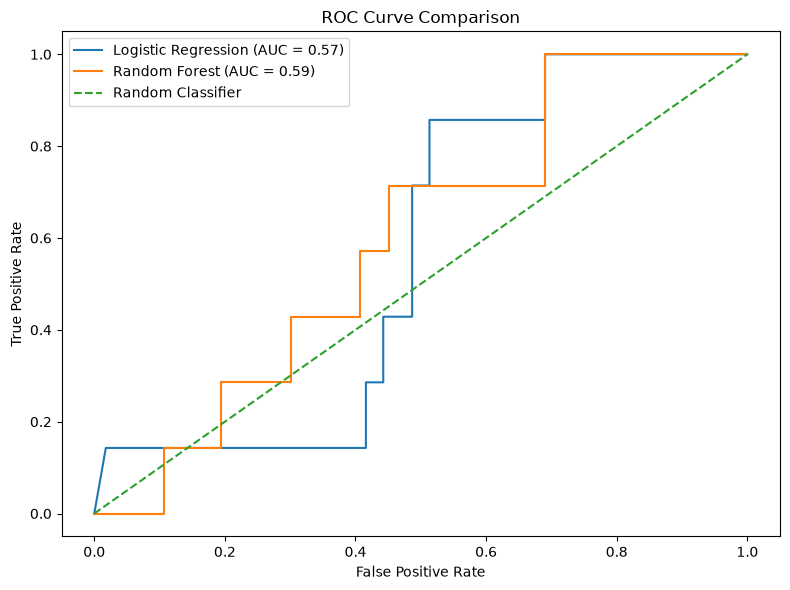

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_logit, tpr_logit, _ = roc_curve(y_test, logit_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

# Calculate AUC
auc_logit = roc_auc_score(y_test, logit_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logit,
    tpr_logit,
    label=f"Logistic Regression (AUC = {auc_logit:.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

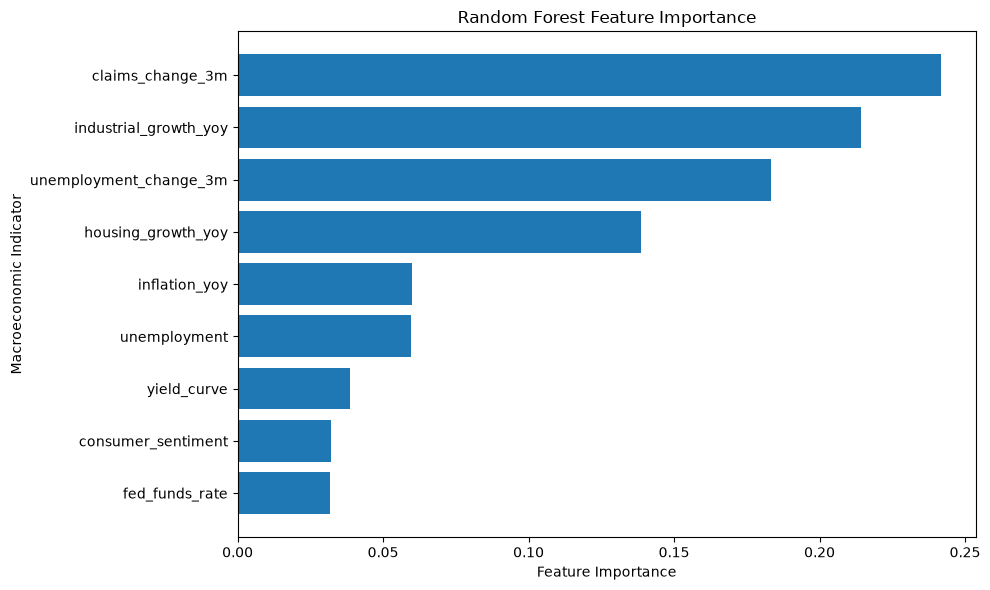

In [74]:
rf_importance_plot = rf_importance.sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_plot["feature"],
    rf_importance_plot["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Macroeconomic Indicator")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

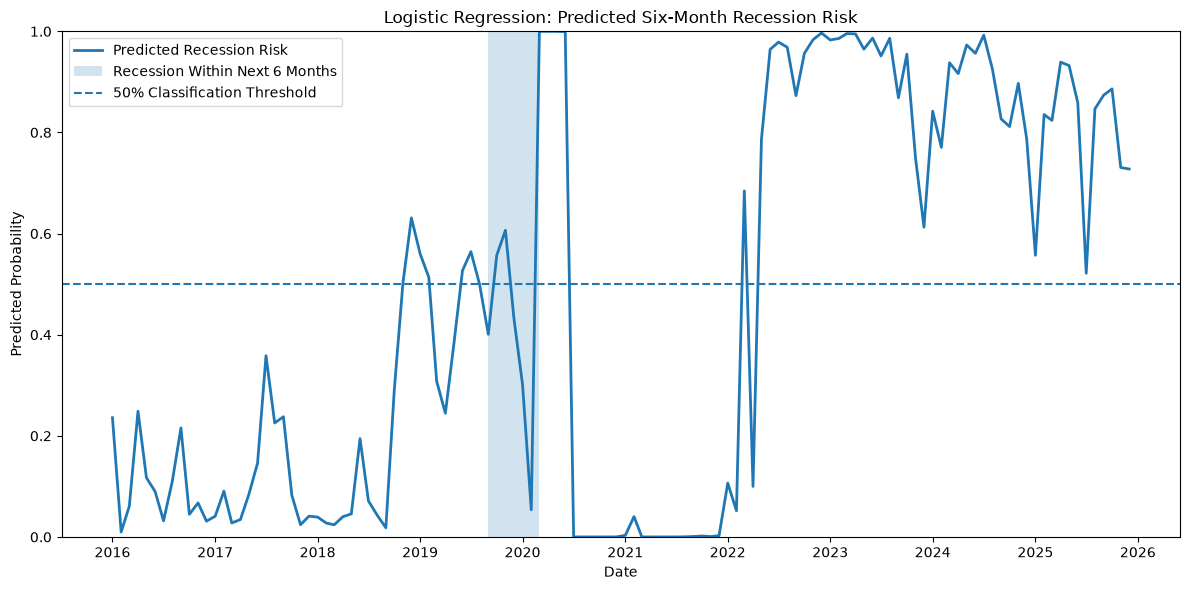

In [75]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_results["date"],
    test_results["predicted_probability"],
    linewidth=2,
    label="Predicted Recession Risk"
)

plt.fill_between(
    test_results["date"],
    0,
    1,
    where=test_results["recession_next_6m"] == 1,
    alpha=0.2,
    label="Recession Within Next 6 Months"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% Classification Threshold"
)

plt.ylim(0, 1)

plt.xlabel("Date")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression: Predicted Six-Month Recession Risk")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/recession_risk_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
model_comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)